# German Credit Risk: Evaluation and Preprocessing

Rebuilt a German-credit classification notebook as a reproducible pipeline with preprocessing contained inside cross-validation. Compared logistic regression, random forest and SVM and evaluated the accuracy-versus-minority-class tradeoff. The selected model achieved balanced accuracy of 0.742 on the held-out test set versus 0.710 for the baseline, while openly documenting the reduction in overall accuracy and the limits of this historical dataset.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Used fold-local numeric imputation/scaling and categorical imputation/one-hot encoding inside a pipeline. Compared logistic regression, random forest and SVM using five-fold training cross-validation. Selected by balanced accuracy to account for the minority bad-credit class, then evaluated a held-out 200-record test set.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc,average_precision
Train-only logistic baseline,0.780,0.709524,0.720954,0.772298,0.804048,0.635148
Selected model,0.725,0.741667,0.705874,0.735875,0.809405,0.646273


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.12.2',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'scipy': '1.18.1',
 'seed': 42}

Data fingerprint: b21f3d81db8071257d5ff1deaeba1fd4303b62712e6fcc9715c7a86202cb5871


## Figures

test_confusion_matrix.png


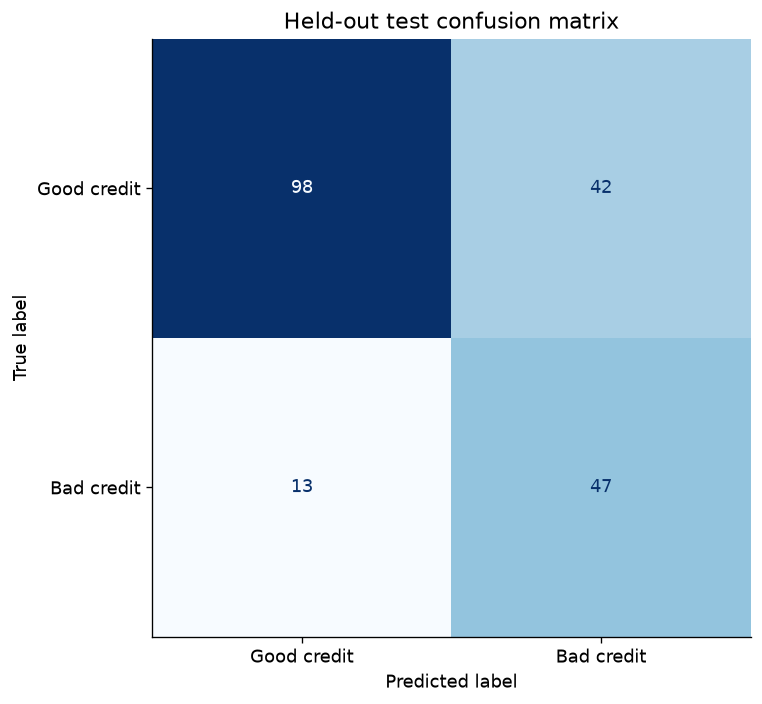

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

The selected balanced model increased test balanced accuracy from 0.710 to 0.742, while overall accuracy fell from 78.0% to 72.5%. This is a documented tradeoff, not an overall accuracy gain. Historical sensitive attributes are retained for assignment comparability; fairness and deployment suitability were not established. The older 71% result is not a controlled baseline.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python train.py --data data/german.data --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)